# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [23]:
%pip show torch

Name: torch
Version: 2.7.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: openml-pytorch, pytorch-lightning, torchaudio, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


In [24]:
%pip install rdkit
%pip install torch_geometric
%pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Note: you may need to restart the kernel to use updated packages.


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Note: you may need to restart the kernel to use updated packages.


In [25]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [26]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [27]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [28]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


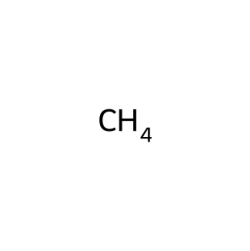

In [29]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.015│     1.562│    -0.243
  C  │  6   │     0.033│     0.061│    -0.072
  O  │  8   │    -1.085│    -0.610│    -0.590
  C  │  6   │     1.305│    -0.710│    -0.236
  C  │  6   │     0.667│    -0.608│     1.137
  C  │  6   │     1.332│     0.140│     2.250
  F  │  9   │     2.206│     1.067│     1.814
  F  │  9   │     0.435│     0.779│     3.024
  F  │  9   │     2.015│    -0.694│     3.053
  H  │  1   │     0.896│     2.043│     0.113
  H  │  1   │    -0.153│     1.803│    -1.301
  H  │  1   │    -0.857│     1.988│     0.316
  H  │  1   │    -1.865│    -0.288│    -0.124
  H  │  1   │     1.246│    -1.669│    -0.736
  H  │  1   │     2.218│    -0.151│    -0.399
  H  │  1   │     0.144│    -1.487│     1.497


SMILE: C[C@@]1(O)C[C@H]1C(F)(F)F


Formation Energy: -66.099
Formation Energy (normalized): 0.97808


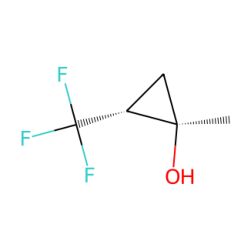

In [30]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [31]:
# Print example of pos, type data
print("pos", pos_data[0])
print("type", type_data[0])


def create_graph_data(pos, typ, fe):
    # Convert to tensor
    pos_tensor = torch.tensor(pos, dtype=torch.float)
    type_tensor = torch.tensor(typ, dtype=torch.long)
    fe_tensor = torch.tensor(fe*std + mu, dtype=torch.float)

    # Create edge index
    num_atoms = len(pos)
    edge_index = []
    for i in range(num_atoms):
        for j in range(num_atoms):
            if i != j:
                edge_index.append([i, j])    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x=type_tensor.unsqueeze(1).float()
    
    # Compute edge attributes (e.g., distances)
    row, col = edge_index
    edge_vec = pos_tensor[row] - pos_tensor[col]
    edge_attr = torch.norm(edge_vec, dim=1, keepdim=True)

    data = Data(x, pos=pos_tensor, edge_index=edge_index, edge_attr=edge_attr, y=fe_tensor)
    return data

# Create graph data for training and testing
train_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in train_idxes]
test_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in test_idxes]

# Create validation set from 10% of training data
val_size = int(0.1 * len(train_graph_data))
train_graph_data, val_graph_data = train_graph_data[:-val_size], train_graph_data[-val_size:]

# Create DataLoader for training and testing
graph_train_loader = DataLoader(train_graph_data, batch_size=128, shuffle=True)
graph_val_loader = DataLoader(val_graph_data, batch_size=128, shuffle=False)
graph_test_loader = DataLoader(test_graph_data, batch_size=128, shuffle=False)

print(train_graph_data[0])

pos [[-1.2700e-02  1.0858e+00  8.0000e-03]
 [ 2.2000e-03 -6.0000e-03  2.0000e-03]
 [ 1.0117e+00  1.4638e+00  3.0000e-04]
 [-5.4080e-01  1.4475e+00 -8.7660e-01]
 [-5.2380e-01  1.4379e+00  9.0640e-01]]
type [6 1 1 1 1]
Data(x=[16, 1], edge_index=[2, 240], edge_attr=[240, 1], y=-68.8128433227539, pos=[16, 3])


c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [32]:
class Node_Embedding(nn.Module):
    def __init__ (self, node_feature_dim, node_embedding_dim):
        super(Node_Embedding, self).__init__()
        self.embedding_dim = node_embedding_dim
        self.feature_dim = node_feature_dim
        self.embedding = nn.Linear(node_feature_dim, node_embedding_dim)
    def forward(self, nodes):
        assert nodes.size(-1) == self.feature_dim, 'wrong input dimension of node features!'
        out = self.embedding(nodes)
        return out
    
# Message Passing Layer
class MP_layer(nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MP_layer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1)
        edge_messages_output = self.edge_network(edge_messages_input)
        
        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )

        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor
    
# GNN
class FormationEnergyGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3):
        super(FormationEnergyGNN, self).__init__()
        self.node_to_emb = Node_Embedding(node_feat_dim, hidden_dim)
        self.forward_net = nn.Sequential(
            *[MP_layer(hidden_dim, activation) for i in range(num_layers)]
        )
        self.to_pred = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model
        
        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))

        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x)

        x = self.to_pred(out)
        return x
    
gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
gnn = gnn.to(device)

Using device: cuda


In [33]:
def train_gnn(model, train_loader, optimizer, criterion, device):
    model.train()
    for data in train_loader:
        data.to(device)
        optimizer.zero_grad()
        output = model(data.x, data.edge_index, data.batch)
        y = data.y.to(device)
        loss = criterion(output.squeeze(-1),y)
        loss.backward()
        optimizer.step()

def test_gnn(model, test_loader, criterion, device):
    model.eval()
    # Evaluate with R squared score
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data.to(device)
            output = model(data.x, data.edge_index, data.batch)
            y = data.y.to(device)
            loss = criterion(output.squeeze(-1), y)
            total_loss += loss.item()

    return total_loss / len(test_loader)

def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_task1():
    optimizer = torch.optim.Adam(gnn.parameters(), lr = 0.0001)
    criterion = nn.MSELoss()
    num_epochs = 20
    min_val_loss = float('inf')
    for epoch in range(num_epochs):
        train_gnn(gnn, graph_train_loader, optimizer, criterion, device)
        train_loss = test_gnn(gnn, graph_train_loader, criterion, device)
        val_loss = test_gnn(gnn, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(gnn.state_dict(), 'gnn_model_geometric.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

train_model = True
if train_model:
    train_task1()


Epoch 1/20, Train Loss: 10.6347, Val Loss: 10.7956
Epoch 2/20, Train Loss: 10.4074, Val Loss: 10.5304
Epoch 3/20, Train Loss: 7.4149, Val Loss: 7.4978
Epoch 4/20, Train Loss: 3.1272, Val Loss: 3.1655
Epoch 5/20, Train Loss: 3.6193, Val Loss: 3.6628
Epoch 6/20, Train Loss: 1.8222, Val Loss: 1.8422
Epoch 7/20, Train Loss: 1.4304, Val Loss: 1.4420
Epoch 8/20, Train Loss: 2.0717, Val Loss: 2.1008
Epoch 9/20, Train Loss: 2.5986, Val Loss: 2.5972
Epoch 10/20, Train Loss: 1.4167, Val Loss: 1.4181
Epoch 11/20, Train Loss: 1.5329, Val Loss: 1.5511
Epoch 12/20, Train Loss: 3.4992, Val Loss: 3.4909
Epoch 13/20, Train Loss: 1.6923, Val Loss: 1.7091
Epoch 14/20, Train Loss: 1.5165, Val Loss: 1.5283
Epoch 15/20, Train Loss: 1.5916, Val Loss: 1.5839
Epoch 16/20, Train Loss: 2.0079, Val Loss: 1.9919
Epoch 17/20, Train Loss: 1.9887, Val Loss: 1.9704
Epoch 18/20, Train Loss: 1.2734, Val Loss: 1.2868
Epoch 19/20, Train Loss: 1.3296, Val Loss: 1.3171
Epoch 20/20, Train Loss: 1.2484, Val Loss: 1.2432


In [34]:
# Evaluate on test set
y_true = []
y_pred = []
with torch.no_grad():
    gnn.load_state_dict(torch.load("gnn_model_geometric.pt"))
    gnn.eval()
    for data in graph_test_loader:
        data.to(device)
        output = gnn(data.x, data.edge_index, data.batch)
        y_true.append(data.y.cpu())
        y_pred.append(output.cpu())

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred).squeeze(-1)
print("y_pred", y_pred)
print("y_true", y_true)

r2 = r2_score(y_true, y_pred)
print(f'R squared score: {r2:.4f}')

y_pred tensor([-80.1962, -87.8414, -74.4544,  ..., -47.7742, -81.4497, -72.9747])
y_true tensor([-81.0877, -88.0048, -74.0629,  ..., -48.0841, -81.9360, -72.6332])
R squared score: 0.9887


## Task 2

In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


subset_sizes = [100,300,1000,3000,10000]

def train_task2(subset_size):
    task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
    task2_gnn = task2_gnn.to(device)
    optimizer = torch.optim.Adam(task2_gnn.parameters(), lr=0.0001)
    criterion = nn.MSELoss()
    num_epochs = 20
    min_val_loss = float('inf')
    
    subset_train_loader = DataLoader(train_graph_data[:subset_size], batch_size=128, shuffle=True)
    
    for epoch in range(num_epochs):
        
        train_gnn(task2_gnn, subset_train_loader, optimizer, criterion, device)
        train_loss = test_gnn(task2_gnn, subset_train_loader, criterion, device)
        val_loss = test_gnn(task2_gnn, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(task2_gnn.state_dict(), f'task2_gnn_geometric_{subset_size}.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')


if train_model == True:
    for size in subset_sizes:
        print(f'Training with subset size: {size}')
        train_task2(size)


def evaluate_task2(subset_sizes):
    results = []
    for subset_size in subset_sizes:
        task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
        task2_gnn = task2_gnn.to(device)

Using device: cuda
Training with subset size: 100
Epoch 1/20, Train Loss: 5689.9897, Val Loss: 5668.5630
Epoch 2/20, Train Loss: 5653.0518, Val Loss: 5634.7226
Epoch 3/20, Train Loss: 5616.7168, Val Loss: 5601.4834
Epoch 4/20, Train Loss: 5579.9316, Val Loss: 5567.3537
Epoch 5/20, Train Loss: 5540.9312, Val Loss: 5531.4176
Epoch 6/20, Train Loss: 5500.6519, Val Loss: 5494.3349
Epoch 7/20, Train Loss: 5459.2036, Val Loss: 5455.3941
Epoch 8/20, Train Loss: 5417.2988, Val Loss: 5414.9212
Epoch 9/20, Train Loss: 5375.5088, Val Loss: 5373.0777
Epoch 10/20, Train Loss: 5334.7925, Val Loss: 5331.7820
Epoch 11/20, Train Loss: 5297.6812, Val Loss: 5293.0377
Epoch 12/20, Train Loss: 5265.4937, Val Loss: 5257.6104
Epoch 13/20, Train Loss: 5235.2231, Val Loss: 5225.8316
Epoch 14/20, Train Loss: 5206.2544, Val Loss: 5196.2319
Epoch 15/20, Train Loss: 5177.7549, Val Loss: 5167.6592
Epoch 16/20, Train Loss: 5148.4331, Val Loss: 5138.6465
Epoch 17/20, Train Loss: 5117.9453, Val Loss: 5108.9911
Epoch 1

In [ ]:
# Evaluate on test set for each subset size
task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
device = torch.device("cpu")
r2_scores = []
mse_losses = []
for size in subset_sizes:
    task2_gnn.load_state_dict(torch.load(f'task2_gnn_geometric_{size}.pt'))
    y_true = []
    y_pred = []
    with torch.no_grad():
        task2_gnn.eval()
        for data in graph_test_loader:
            data.to(device)
            output = task2_gnn(data.x, data.edge_index, data.batch)
            y_true.append(data.y.cpu())
            y_pred.append(output.cpu())

    y_true = torch.cat(y_true)
    y_pred = torch.cat(y_pred).squeeze(-1)
    

    r2 = r2_score(y_true, y_pred)
    mse = F.mse_loss(y_pred, y_true).item()
    r2_scores.append(r2)
    mse_losses.append(mse)
    print(f'Subset size: {size}, R squared score: {r2:.4f}, MSE: {mse:.4f}')



Subset size: 100, R squared score: -45.6771, MSE: 5010.3853
Subset size: 300, R squared score: -13.0910, MSE: 1512.5492
Subset size: 1000, R squared score: 0.1113, MSE: 95.3983
Subset size: 3000, R squared score: 0.9027, MSE: 10.4405
Subset size: 10000, R squared score: 0.9576, MSE: 4.5479


In [37]:
# calculate the area under the r2 curve for subset sizes
def calculate_auc_r2(r2_scores):
    return np.trapz(r2_scores, x=subset_sizes)

def calculate_auc_mse(mse_losses):
    return np.trapz(mse_losses, x=subset_sizes)

auc_r2 = calculate_auc_r2(r2_scores)
auc_mse = calculate_auc_mse(mse_losses)
print(f'AUC R squared: {auc_r2:.4f}')
print(f'AUC MSE: {auc_mse:.4f}')


AUC R squared: -2894.4326
AUC MSE: 1373373.2720


## Task 3

In [38]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [39]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [40]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)

In [41]:
def valid(smiles):
    # Percentage of valid strings in the dataset
    valid_count = sum(is_valid_smiles(s) for s in smiles)
    total_count = len(smiles)
    return valid_count / total_count

def uniqueness(smiles):
    # Percentage of unique valid strings
    valid_count = sum(is_valid_smiles(s) for s in smiles)
    unique_smiles = set(canonicalize(s) for s in smiles if is_valid_smiles(s))
    return len(unique_smiles) / valid_count if valid_count > 0 else 0

def novelty(smiles, train_set):
    # Percentage of valid strings not in the training set
    valid_smiles = [s for s in smiles if is_valid_smiles(s)]
    unique_smiles = set(canonicalize(s) for s in valid_smiles)
    train_set_smiles = set(canonicalize(s) for s in train_set if is_valid_smiles(s))
    novel_smiles = unique_smiles - train_set_smiles
    return len(novel_smiles) / len(unique_smiles) if unique_smiles else 0

In [42]:
from collections import Counter

class Vocab:
    def __init__(self, smiles_list):
        chars = set()
        for s in smiles_list:
            chars.update(s)

        self.special_tokens = ['<pad>', '<sos>', '<eos>', '<unk>']
        self.char2idx = {ch: idx for idx, ch in enumerate(self.special_tokens + sorted(chars))}
        self.idx2char = {idx: ch for ch, idx in self.char2idx.items()}

        self.pad_token = '<pad>'
        self.sos_token = '<sos>'
        self.eos_token = '<eos>'
        self.unk_token = '<unk>'

    def __len__(self):
        return len(self.char2idx)

    def encode(self, smiles):
        return [self.char2idx.get(self.sos_token)] + \
               [self.char2idx.get(c, self.char2idx[self.unk_token]) for c in smiles] + \
               [self.char2idx.get(self.eos_token)]

    def decode(self, indices):
        tokens = []
        for idx in indices:
            char = self.idx2char.get(idx, self.unk_token)
            if char == self.eos_token:
                break
            if char not in [self.sos_token, self.pad_token]:
                tokens.append(char)
        return ''.join(tokens)



In [43]:
from sklearn.model_selection import train_test_split

def tokenize(smile, vocab):
    tokens = [vocab['<sos>']] + [vocab[c] for c in smile] + [vocab['<eos>']]
    return torch.tensor(tokens, dtype=torch.long)

class SmilesDataset(torch.utils.data.Dataset):
    def __init__(self, smiles_list, vocab):
        self.data = [tokenize(smile, vocab) for smile in smiles_list]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx][:-1]
        y = self.data[idx][1:]
        return x, y

def pad_collate(batch):
    x_batch, y_batch = zip(*batch)
    x_batch = nn.utils.rnn.pad_sequence(x_batch, batch_first=True, padding_value=vocab.char2idx['<pad>'])
    y_batch = nn.utils.rnn.pad_sequence(y_batch, batch_first=True, padding_value=vocab.char2idx['<pad>'])
    return x_batch, y_batch

train_smiles_all = [smiles_data[i] for i in train_idxes]
vocab = Vocab(train_smiles_all)
vocab_size = len(vocab)


train_smiles, val_smiles = train_test_split(train_smiles_all, test_size=0.2, random_state=42)

train_smiles_dataset = SmilesDataset(train_smiles, vocab.char2idx)
val_smiles_dataset = SmilesDataset(val_smiles, vocab.char2idx)
train_smiles_loader = torch.utils.data.DataLoader(train_smiles_dataset, batch_size=64, shuffle=True, collate_fn=pad_collate)
val_smiles_loader = torch.utils.data.DataLoader(val_smiles_dataset, batch_size=64, shuffle=True, collate_fn=pad_collate)


In [44]:
class SmilesRNN(nn.Module):
    def __init__(self, vocab_size, emb_size=128, hidden_size=256, num_layers=2):
        super(SmilesRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.encoder = nn.LSTM(emb_size, hidden_size, num_layers, batch_first=True)
        self.decoder = nn.LSTM(emb_size, hidden_size, num_layers, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, target=None, teacher_forcing_ratio=0.5):
        emb = self.embedding(x)
        _, (h, c) = self.encoder(emb)

        batch_size = x.size(0)
        max_len = x.size(1)
        outputs = torch.zeros(batch_size, max_len, vocab_size).to(x.device)

        decoder_input = torch.full((batch_size, 1), vocab.char2idx['<sos>'], dtype=torch.long).to(x.device)

        for t in range(max_len):
            dec_emb = self.embedding(decoder_input)
            out, (h, c) = self.decoder(dec_emb, (h, c))
            logits = self.out(out.squeeze(1))
            outputs[:, t, :] = logits

            use_teacher_forcing = target is not None and torch.rand(1).item() < teacher_forcing_ratio
            next_input = target[:, t].unsqueeze(1) if use_teacher_forcing else logits.argmax(1).unsqueeze(1)
            decoder_input = next_input

        return outputs


In [45]:
device = torch.device("cuda")
model = SmilesRNN(vocab_size=vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.char2idx['<pad>'])

def train_rnn(epochs=10):

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x_batch, y_batch in train_smiles_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch, y_batch)
            loss = criterion(outputs.view(-1, vocab_size), y_batch.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_val, y_val in val_smiles_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                val_outputs = model(x_val, y_val, teacher_forcing_ratio=0.0)
                loss = criterion(val_outputs.view(-1, vocab_size), y_val.view(-1))
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {total_loss/len(train_smiles_loader):.4f}, Val Loss: {val_loss/len(val_smiles_loader):.4f}")

train_rnn()

Epoch 1/10, Train Loss: 0.9129, Val Loss: 0.7850
Epoch 2/10, Train Loss: 0.1748, Val Loss: 0.2417
Epoch 3/10, Train Loss: 0.0655, Val Loss: 0.1845
Epoch 4/10, Train Loss: 0.0385, Val Loss: 0.0937
Epoch 5/10, Train Loss: 0.0293, Val Loss: 0.0836
Epoch 6/10, Train Loss: 0.0222, Val Loss: 0.0682
Epoch 7/10, Train Loss: 0.0180, Val Loss: 0.0705
Epoch 8/10, Train Loss: 0.0151, Val Loss: 0.0527
Epoch 9/10, Train Loss: 0.0124, Val Loss: 0.0450
Epoch 10/10, Train Loss: 0.0110, Val Loss: 0.0505


In [46]:
def generate_smiles(model, max_len=100, num_samples=10):
    model.eval()
    generated = []

    for _ in range(num_samples):
        input_token = torch.tensor([[vocab.char2idx['<sos>']]], dtype=torch.long).to(device) 
        hidden = None
        smile = ''

        for _ in range(max_len):
            emb = model.embedding(input_token)
            output, hidden = model.decoder(emb, hidden) 
            logits = model.out(output.squeeze(1)) 
            probs = F.softmax(logits, dim=-1) 

            token = torch.multinomial(probs, 1)
            token_id = token.item()
            char = vocab.idx2char[token_id]

            if char == '<eos>':
                break
            smile += char

            input_token = token

        generated.append(smile)

    return generated


samples = generate_smiles(model, num_samples=10)
for s in samples:
    print(f"sample: {s}: valid: {is_valid_smiles(s)}")
    print("")


sample: ]oc1: valid: False

sample: nc\5: valid: False

sample: oc14: valid: False

sample: ]oc1: valid: False

sample: H]oo1: valid: False

sample: \o1F: valid: False

sample: H]oc: valid: False

sample: oc4F: valid: False

sample: o2c: valid: False

sample: ]oc1: valid: False

